# 10. sRNA は「転写後」だけでなく「転写途中」でも標的を抑える

> **出典**: Reyer MA, Chennakesavalu S, Heideman EM, et al. (2021) *Kinetic modeling reveals additional regulation at co-transcriptional level by post-transcriptional sRNA regulators.* Cell Reports 36:109764.

SgrS は「**転写後制御** sRNA」の代表とされてきた——成熟した mRNA に結合して翻訳を止め、共分解する。
だがこの論文は、単一細胞イメージング＋速度論モデルで、SgrS が **転写途中の nascent mRNA にも効き**、
実効的な mRNA 生成そのものを下げている（**共転写制御**）ことを突き止めた。

これは 06〜09 と違い、論文に **ODE と実測パラメータ**がある。ここでは論文の構造を代表パラメータで実装し
（比 $\alpha_{ms}/\alpha_m\approx0.46$ は WT 実測値）、「post だけでは足りず、co を足すと合う」を再現する。

## モデル（種: s, m, ms, p）

| 反応 | 意味 |
|---|---|
| $\varnothing\to m$ | 実効転写 $\alpha_m$（**共転写制御ありなら** $\alpha_m\to0.46\,\alpha_m$） |
| $m\to\varnothing$ | mRNA 分解 $\beta_m$ |
| $m+s\rightleftharpoons ms$ | sRNA 結合 $k_{on}/k_{off}$ |
| $ms\to\varnothing$ | 共分解 $\beta_{ms}$ |
| $m\to m+p,\ \ ms\to ms+p$ | 翻訳 $k_x$（結合時は $k_{xs}\ll k_x$） |
| $p\to\varnothing$ | 希釈 $\beta_p$（タンパク質は長寿命） |

3条件を比較: **minus**（sRNAなし）／ **post**（転写後のみ）／ **co**（転写後＋共転写）。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

S, M, MS, P = (Species(x) for x in ['s','m','ms','p'])
A_M, B_M, K_X, B_P = 60.0, 0.2, 2.0, 0.008     # 代表値 (/min)
A_S, B_S = 15.0, 0.1                            # sRNA を ~150 copies に保つ
K_ON, K_OFF, B_MS, K_XS = 0.002, 0.05, 0.4, 0.2
P_CO = 0.46                                     # 共転写制御での実効転写低下 (WT 実測比)
SP = ['s','m','ms','p']
def R(a,b,k): return ReactionRule(a,b,k)

def build(mode):
    a_m_eff = A_M * (P_CO if mode == 'co' else 1.0)
    rules = [R([],[M],a_m_eff), R([M],[],B_M), R([M],[M,P],K_X), R([P],[],B_P)]
    if mode != 'minus':
        rules += [R([],[S],A_S), R([S],[],B_S),
                  R([M,S],[MS],K_ON), R([MS],[M,S],K_OFF),
                  R([MS],[],B_MS), R([MS],[MS,P],K_XS)]
    mdl = NetworkModel()
    for r in rules: mdl.add_reaction_rule(r)
    return mdl

def run(mode, t_end=25.0, ndiv=100):
    y0 = {'s':150.0} if mode != 'minus' else {}
    return run_simulation(t_end, y0=y0, model=build(mode), solver='ode', ndiv=ndiv, species_list=SP).as_array()
print('ready')

ready


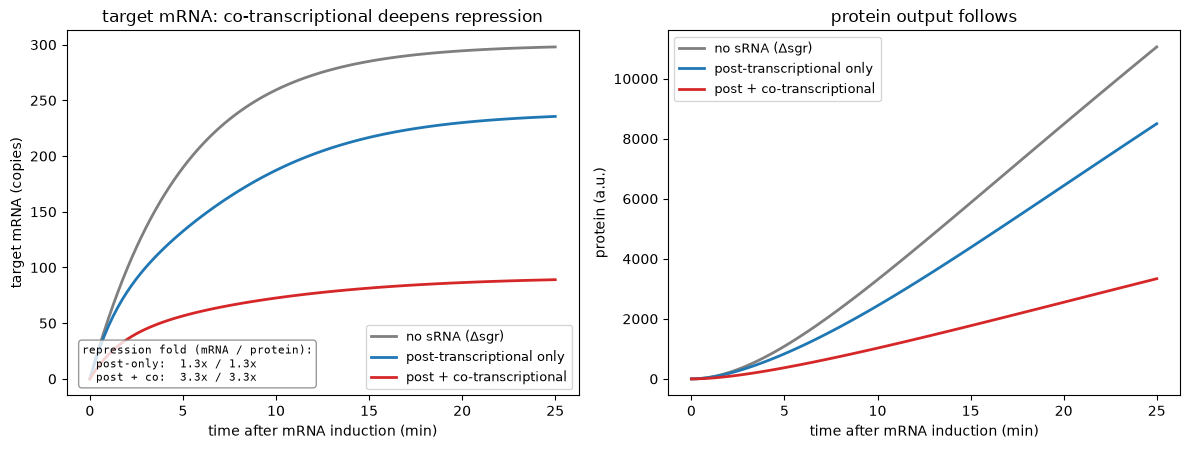

In [2]:
styles = [('minus','C7','no sRNA (Δsgr)'), ('post','C0','post-transcriptional only'),
          ('co','C3','post + co-transcriptional')]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
base = run('minus'); folds = {}
for mode, c, lab in styles:
    a = run(mode)
    ax1.plot(a[:,0], a[:,2], '-', color=c, lw=2, label=lab)   # m
    ax2.plot(a[:,0], a[:,4], '-', color=c, lw=2, label=lab)   # p
    folds[mode] = (base[-1][2]/a[-1][2], base[-1][4]/a[-1][4])
ax1.set_xlabel('time after mRNA induction (min)'); ax1.set_ylabel('target mRNA (copies)')
ax1.set_title('target mRNA: co-transcriptional deepens repression'); ax1.legend(fontsize=9)
ax2.set_xlabel('time after mRNA induction (min)'); ax2.set_ylabel('protein (a.u.)')
ax2.set_title('protein output follows'); ax2.legend(fontsize=9)
ax1.text(0.03,0.03, 'repression fold (mRNA / protein):\n'
         f"  post-only:  {folds['post'][0]:.1f}x / {folds['post'][1]:.1f}x\n"
         f"  post + co:  {folds['co'][0]:.1f}x / {folds['co'][1]:.1f}x",
         transform=ax1.transAxes, fontsize=8, va='bottom', family='monospace',
         bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=.8))
plt.tight_layout(); plt.show()

## 読み取り

- **post-転写だけ（青）**では抑制は浅い（mRNA・タンパク質とも ~1.3倍）。実験で見える強い抑制の
  「深さ」を説明できない——論文 Fig.3A で post モデルが振幅を再現できなかったのと同じ。
- **共転写制御を足す（赤）**と、実効転写が 0.46 倍に落ち、抑制が ~3倍に深まる。これで実測の強い抑制と合う（Fig.3B）。
- 生物学的には: SgrS は成熟 mRNA を壊すだけでなく、**転写されつつある mRNA にも結合して Rho 依存の途中終結を促す**らしく、
  「転写後制御 sRNA」という分類名の裏で、もっと早い段階から効いている。

**02〜09 との関係**: これまでは反応の構造や Hfq を変えて挙動を探ってきた。10 は **実測パラメータで toy モデルを定量化**し、
「モデルとデータの食い違いから新しい制御（共転写）を発見する」という、システム生物学の醍醐味を再現している。

> **注**: 本notebookの絶対パラメータは代表値。論文は単一細胞 FISH+蛍光で $\alpha_m,k_x,k_{on},k_{off},\beta_{ms}$ 等を推定し、
> $\alpha_{ms}\approx0.46\,\alpha_m$（WT）を得た。厳密な値は論文の supplement 参照。

## 発展課題（自作）

1. `P_CO` を 1.0（共転写なし）→0.2（強い共転写）に振り、抑制の深さがどう動くか。実測の 0.46 はどのあたり？
2. `K_XS`（結合 mRNA の翻訳）を 0 にすると、mRNA と protein の抑制比はどうずれる？ 翻訳阻害と分解の寄与を分ける。
3. sRNA 誘導を t=0 で「オン」にする動的シナリオ（`∅->s` を途中から入れる）に変え、応答の時間差を見る。
4. [[bio-a_hfq-phylogenetics]]: 共転写制御は Rho 依存終結に依存する。sRNA/標的の配列・ゲノム配置の進化が
   「post だけか co も効くか」を左右しうる。系統ごとの制御様式の違いとして考える。